## Function Transformer

1- log Transformer

2- Square and Squareroot Transformer

3- Reciprocal Transformer

This technique is used when the data is not normally distributed

## Power Transformer

Used to reduce skewness.

Methods:

1-Yeo-Johnson: Supports negative values.

2-Box-Cox: Positive values only.

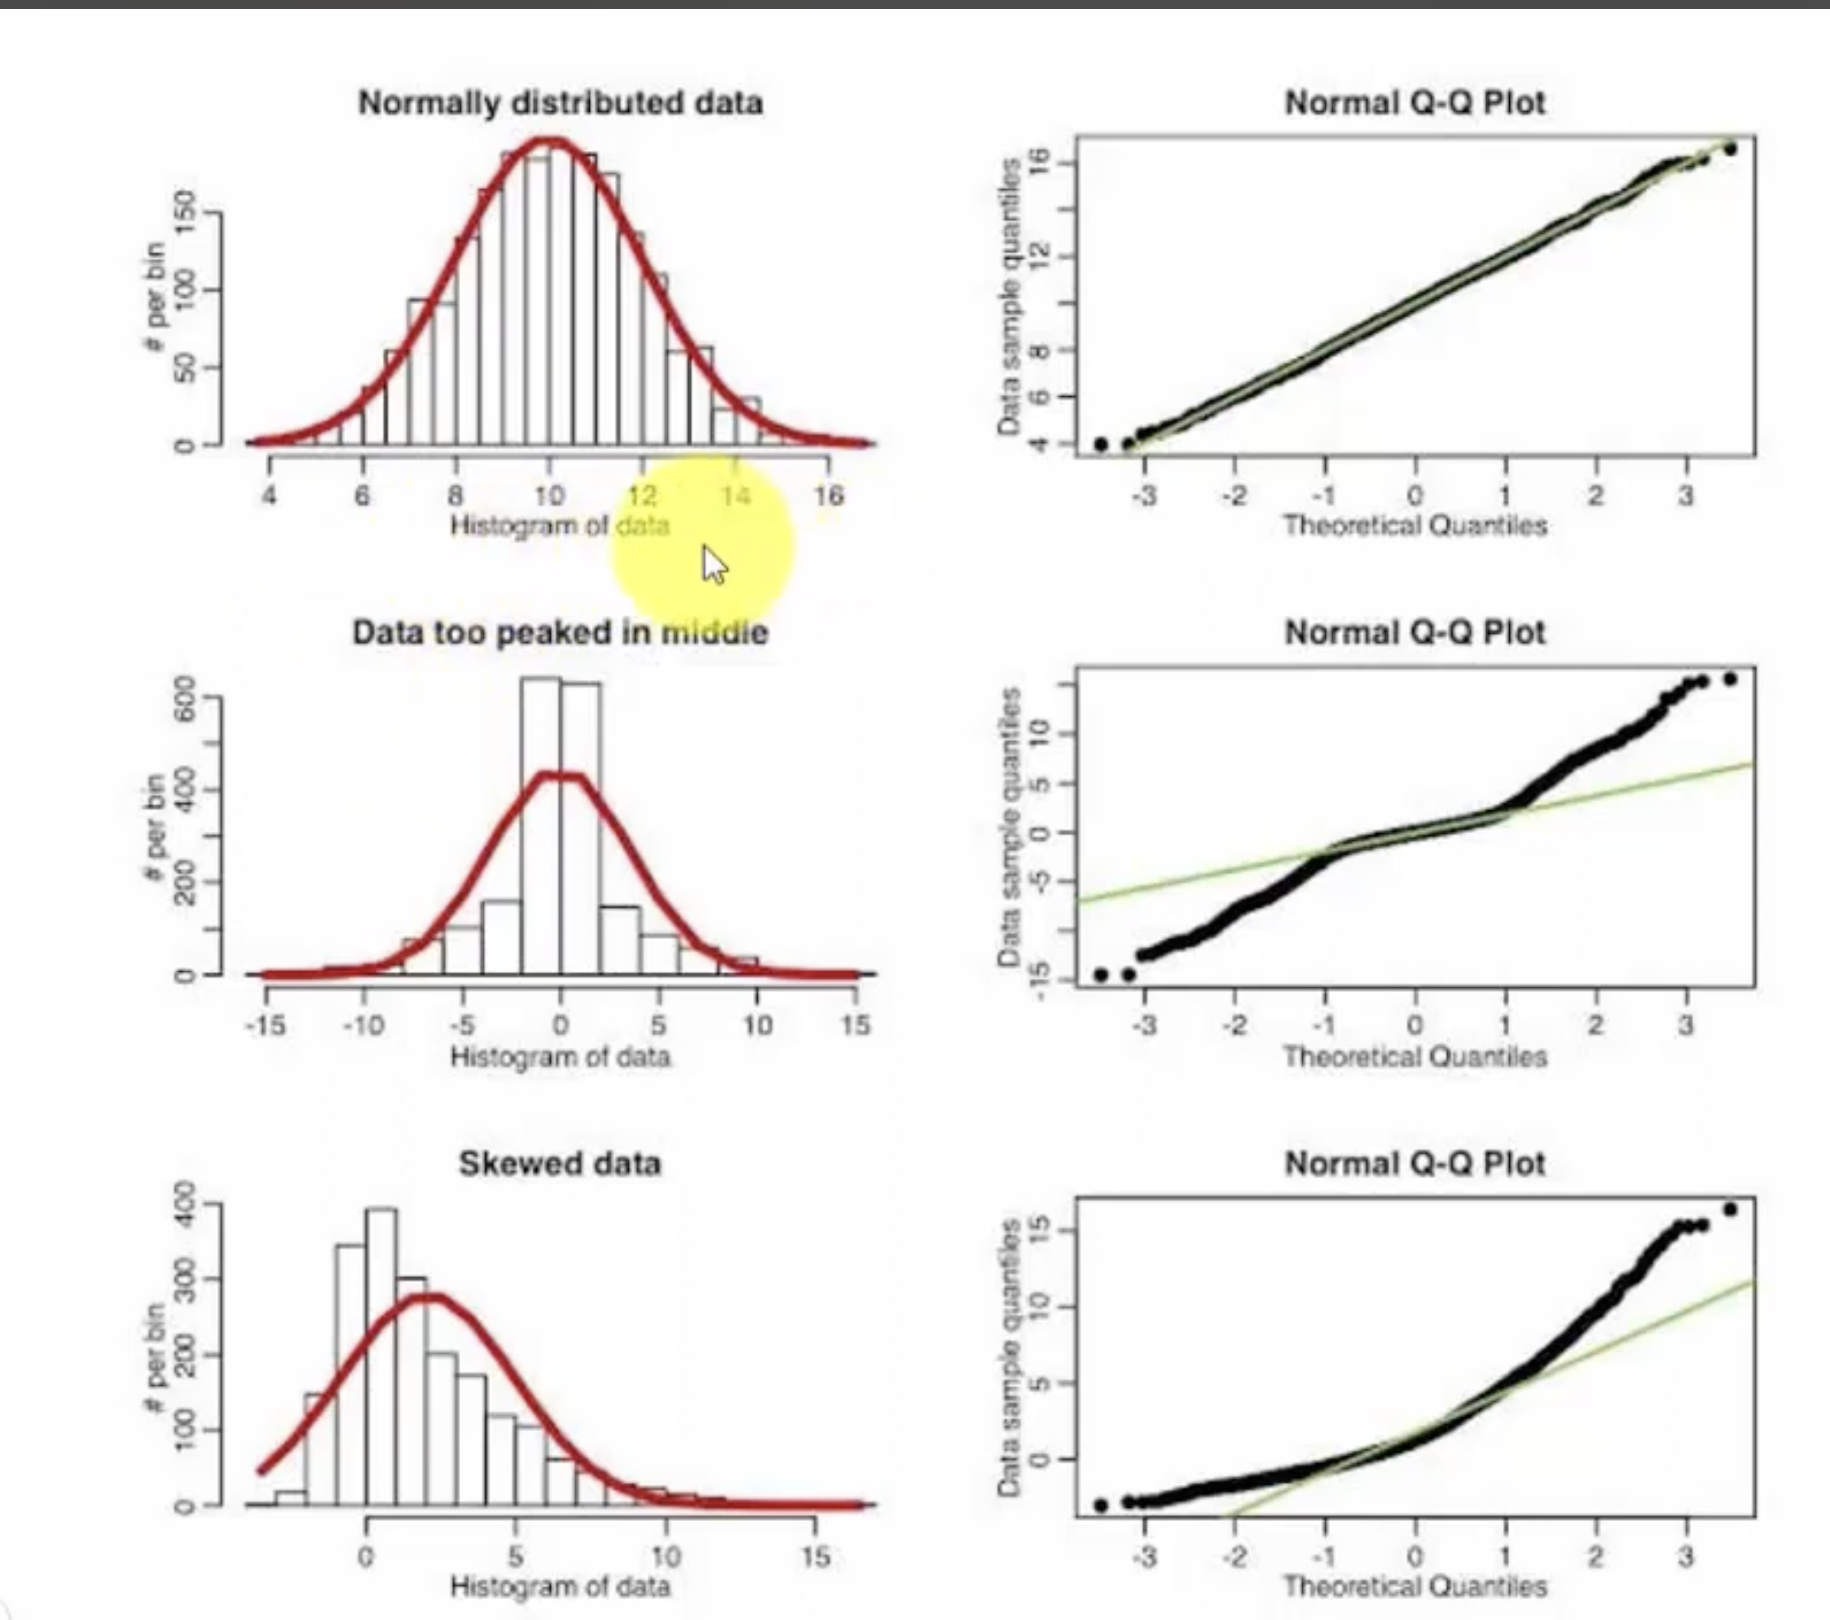

## Q- How to know data is normally distributed or not?

Ans: Used two plots 1-distplot and QQ plot

## Applying Function Transformer

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import FunctionTransformer


In [37]:
df=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/10 titanic.csv',usecols=['Age','Fare','Survived'])
df

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875
...,...,...,...
413,0,NaN,8.0500
414,1,39.0,108.9000
415,0,38.5,7.2500
416,0,NaN,8.0500


In [38]:
df.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [39]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Fare']=df['Fare'].fillna(df['Fare'].mean())

In [40]:
X=df.iloc[:,1:3]
y=df.iloc[:,0]

In [41]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Text(0.5, 1.0, 'QQ Plot-Fare')

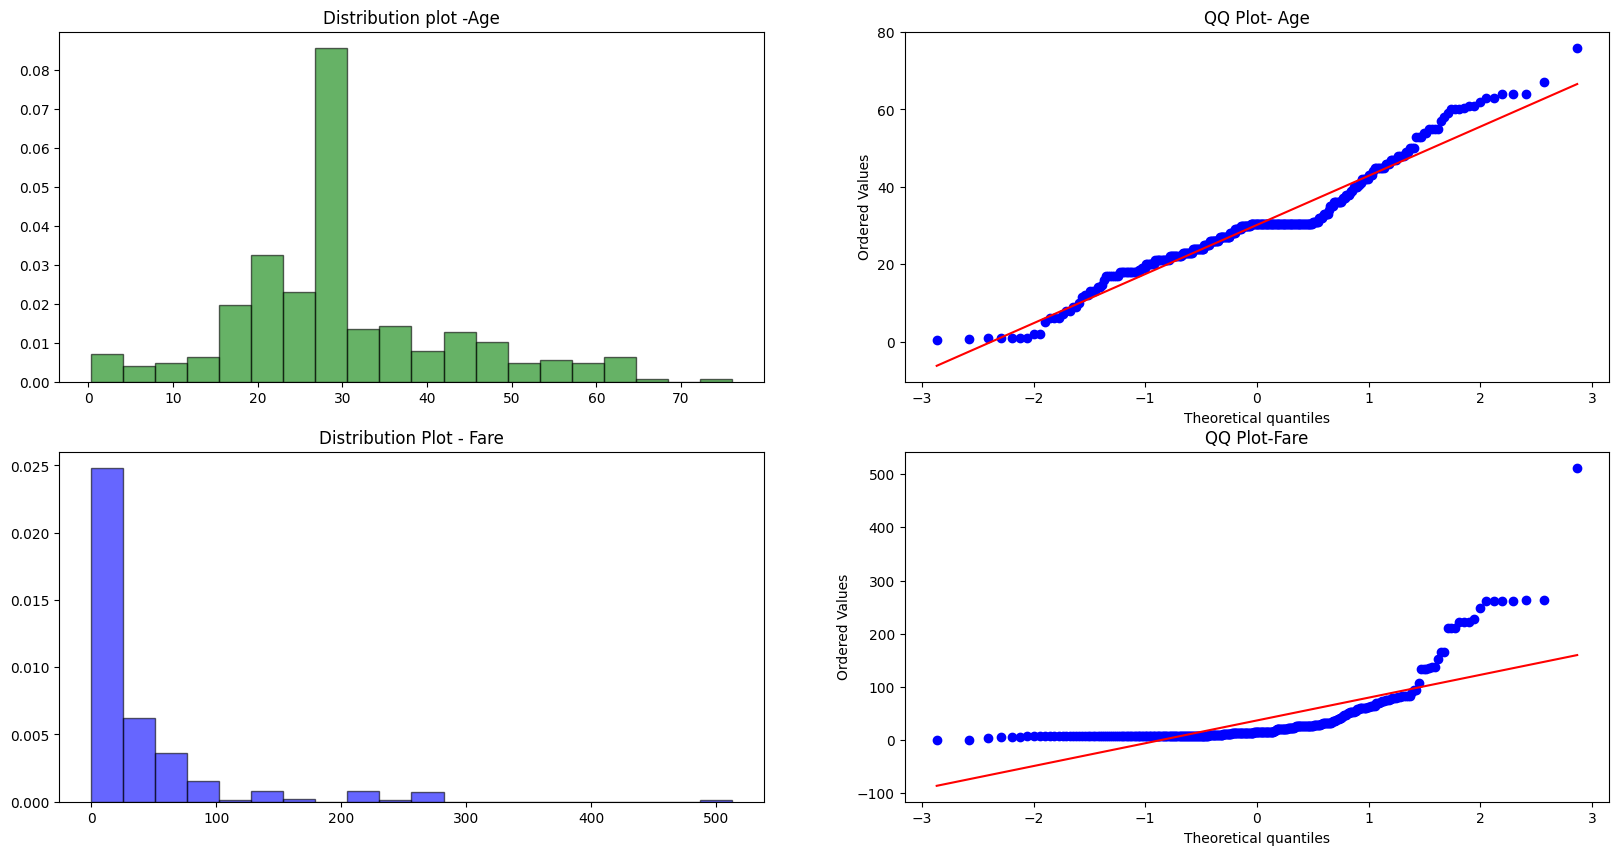

In [42]:
## create subplots with 2 rows and 2 cols

fig, axs= plt.subplots(2,2,figsize=(20,10))

## plotting distribution for the age

axs[0,0].hist(X_train['Age'],bins=20,density=True,alpha=0.6,color='g',edgecolor='black')
axs[0,0].set_title('Distribution plot -Age')

## plot the first QQ Plot for age
stats.probplot(X_train['Age'],dist='norm',plot=axs[0,1])
axs[0,1].set_title('QQ Plot- Age')
## plot the 2nd distribuution for fare

axs[1,0].hist(X_train['Fare'],color='b',density=True,bins=20,edgecolor='black',alpha=0.6)
axs[1,0].set_title('Distribution Plot - Fare')

## plot the second QQ for Fare

stats.probplot(X_train['Fare'],dist='norm',plot=axs[1,1])
axs[1,1].set_title('QQ Plot-Fare')

## Training model before Function Transformer

In [43]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
y_pred=clf.predict(X_test)
y_pred1=clf2.predict(X_test)

print('Accuracy LR',accuracy_score(y_test,y_pred))
print('Accuracy DT',accuracy_score(y_test,y_pred1))

Accuracy LR 0.6071428571428571
Accuracy DT 0.5476190476190477


## Log Transformer

In [45]:
trf=FunctionTransformer(func=np.log1p)
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
y_pred=clf.predict(X_test_transformed)
y_pred1=clf2.predict(X_test_transformed)
print('Accuracy LR',accuracy_score(y_test,y_pred))
print('Accuracy DT',accuracy_score(y_test,y_pred1))

Accuracy LR 0.6190476190476191
Accuracy DT 0.5714285714285714


In [46]:
X_train_transformed

,Age,Fare
336,3.496508,2.639057
31,3.218876,3.481240
84,3.442742,2.460298
287,3.218876,4.422049
317,2.995732,2.442347
...,...,...
71,3.091042,2.185579
106,3.091042,2.177113
270,3.850148,4.333909
348,3.218876,2.674149


Text(0.5, 1.0, 'QQ Plot-Fare')

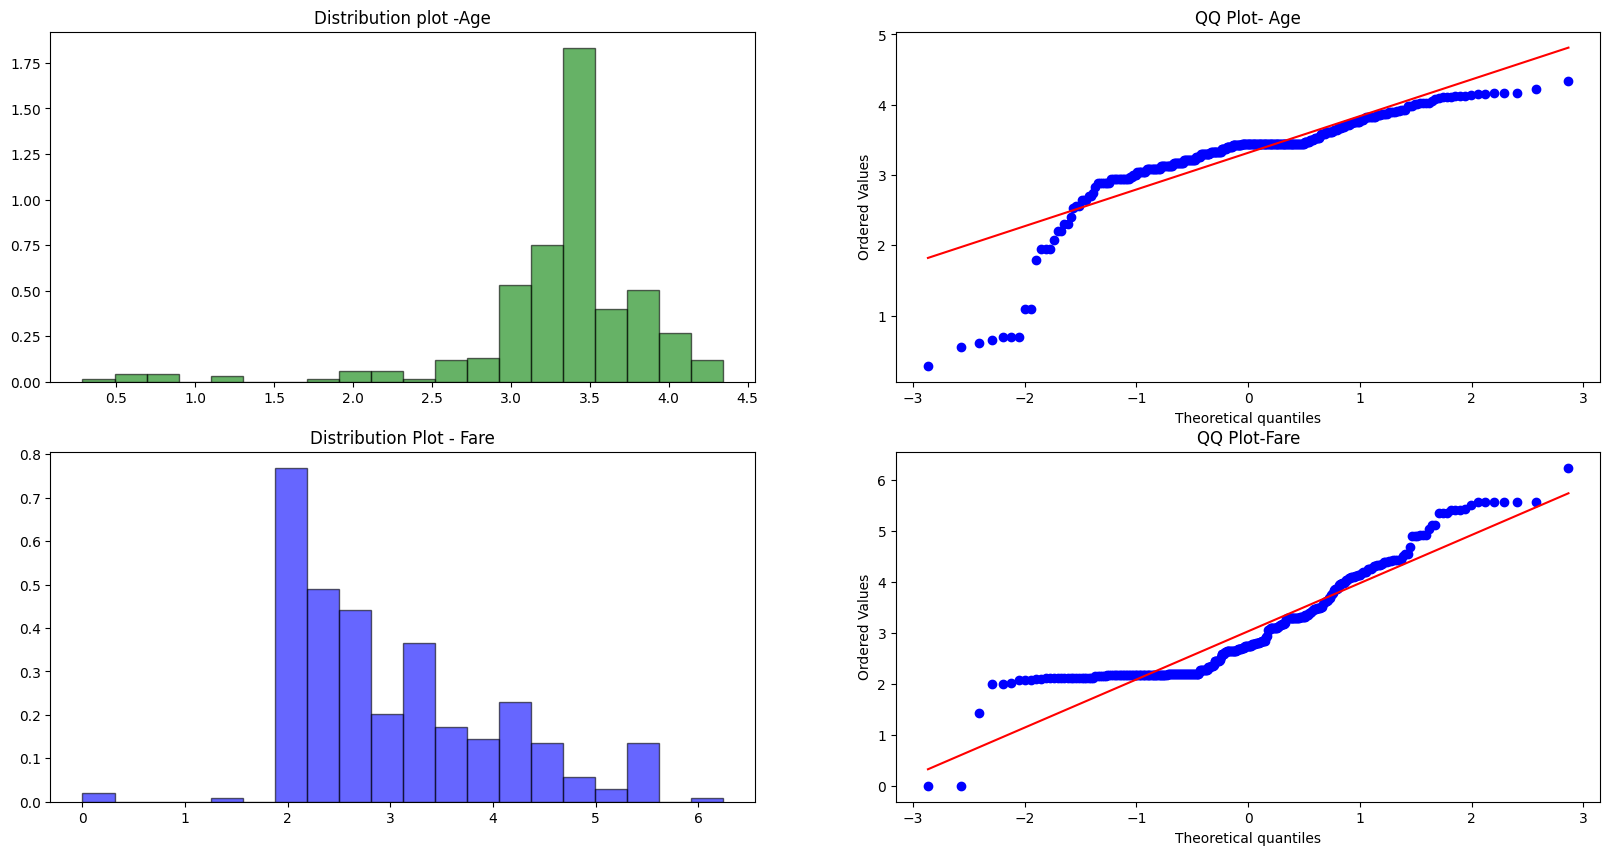

In [ ]:
## create subplots with 2 rows and 2 cols

fig, axs= plt.subplots(2,2,figsize=(20,10))

## plotting distribution for the age

axs[0,0].hist(X_train_transformed['Age'],bins=20,density=True,alpha=0.6,color='g',edgecolor='black')
axs[0,0].set_title('Distribution plot -Age')

## plot the first QQ Plot for age
stats.probplot(X_train_transformed['Age'],dist='norm',plot=axs[0,1])
axs[0,1].set_title('QQ Plot- Age')
## plot the 2nd distribuution for fare

axs[1,0].hist(X_train_transformed['Fare'],color='b',density=True,bins=20,edgecolor='black',alpha=0.6)
axs[1,0].set_title('Distribution Plot - Fare')

## plot the second QQ for Fare

stats.probplot(X_train_transformed['Fare'],dist='norm',plot=axs[1,1])
axs[1,1].set_title('QQ Plot-Fare')


## this makes skewed data more closer to normal distribution

## Reciprocal Transformer

In [49]:
## define the reciprocal function

def reciprocal_transform(X):
    ## add small const value to avoid div by 0
    X=X+1e-6
    return 1/X

## create functional transformer
trf=FunctionTransformer(func=reciprocal_transform)

## Apply the transformation on train and test data
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)


clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
y_pred=clf.predict(X_test_transformed)
y_pred1=clf2.predict(X_test_transformed)
print('Accuracy LR',accuracy_score(y_test,y_pred))
print('Accuracy DT',accuracy_score(y_test,y_pred1))

Accuracy LR 0.6071428571428571
Accuracy DT 0.5595238095238095


## Square transformer

In [53]:
def square_transform(X):
    return X**2

## create functional transformer
trf=FunctionTransformer(func=square_transform)

## Apply the transformation on train and test data
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)


clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
y_pred=clf.predict(X_test_transformed)
y_pred1=clf2.predict(X_test_transformed)
print('Accuracy LR',accuracy_score(y_test,y_pred))
print('Accuracy DT',accuracy_score(y_test,y_pred1))

Accuracy LR 0.6071428571428571
Accuracy DT 0.5357142857142857


## Square root transformer

In [54]:
def squareroot_transform(X):
    return np.sqrt(X)

trf=FunctionTransformer(func=squareroot_transform)

## Apply the transformation on train and test data
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)


clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
y_pred=clf.predict(X_test_transformed)
y_pred1=clf2.predict(X_test_transformed)
print('Accuracy LR',accuracy_score(y_test,y_pred))
print('Accuracy DT',accuracy_score(y_test,y_pred1))

Accuracy LR 0.6190476190476191
Accuracy DT 0.5595238095238095


## Power Transformers

## Box Cox Transformer

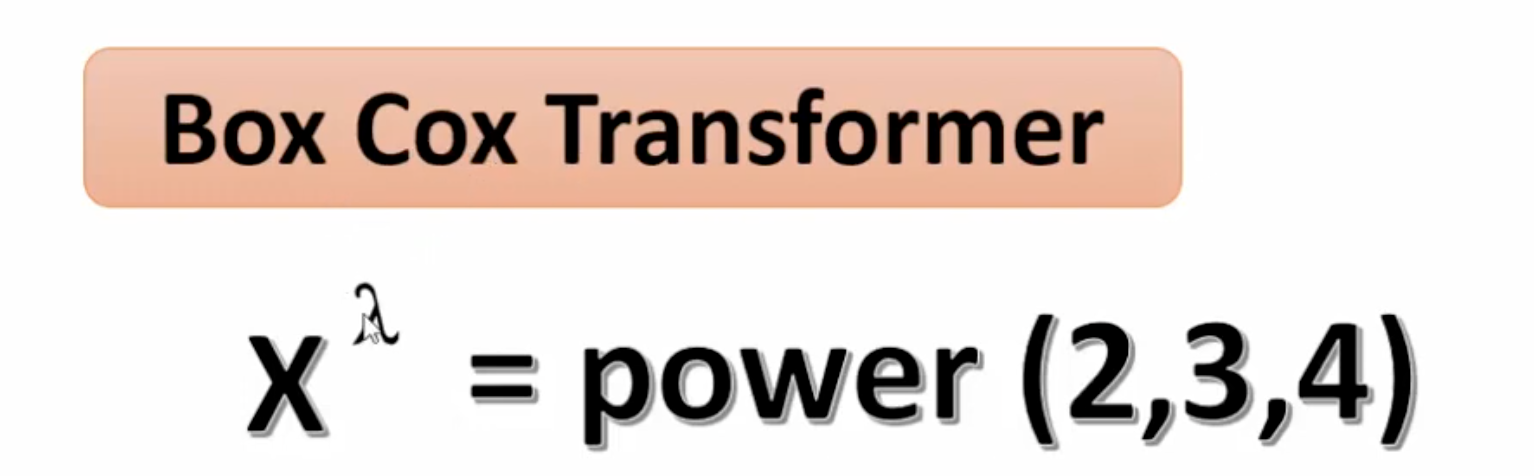

but boxcox fails for negative values and 0 values

## Yeo-Johnson Transformer

works for both negative and zero values

In [56]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

df=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/12 concrete.csv')

In [57]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [60]:
## TRAIN-TEST SPLIT

X=df.drop(columns=['Strength'])
y=df.iloc[:,-1]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Checking distribution

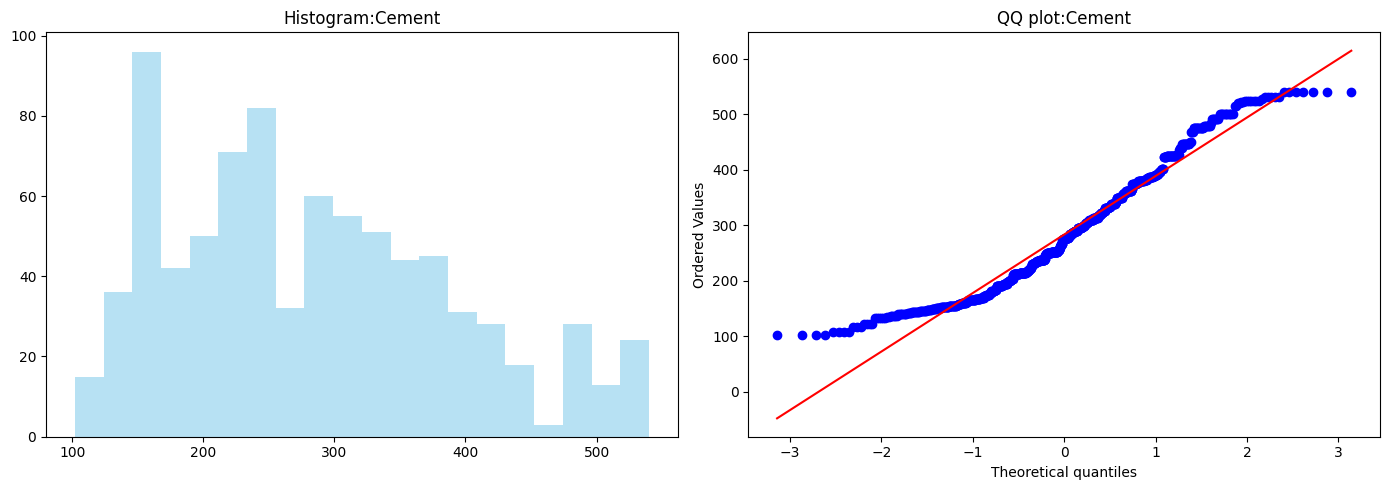

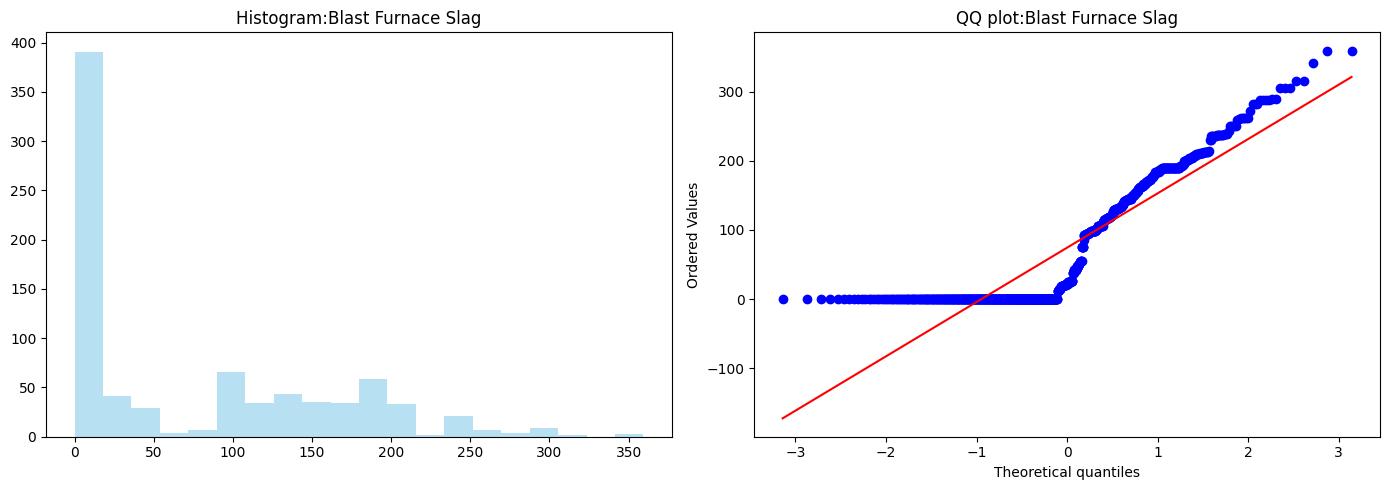

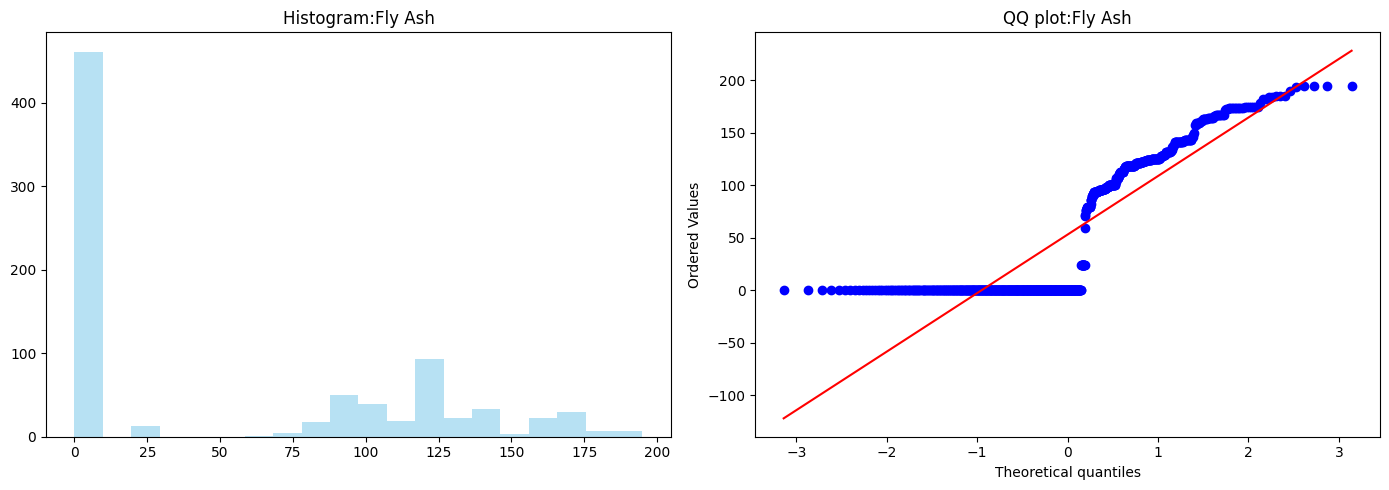

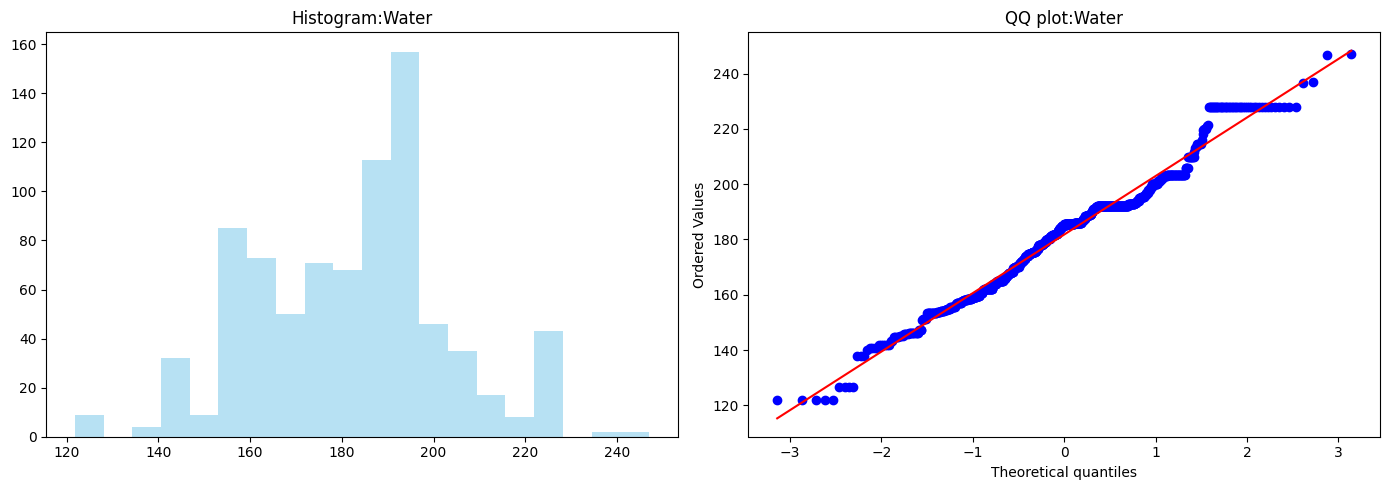

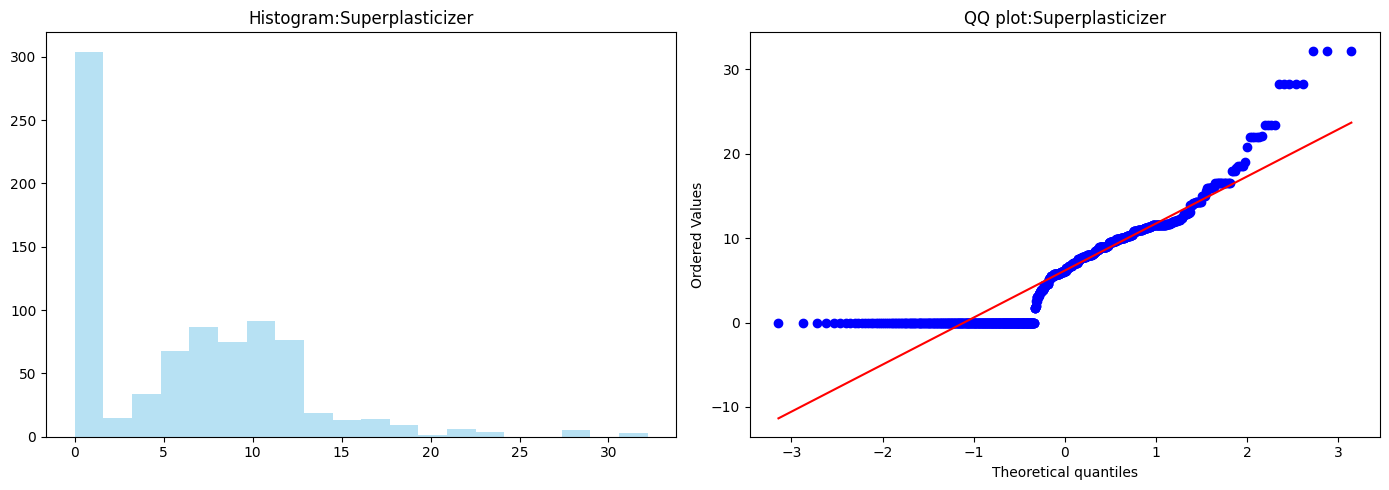

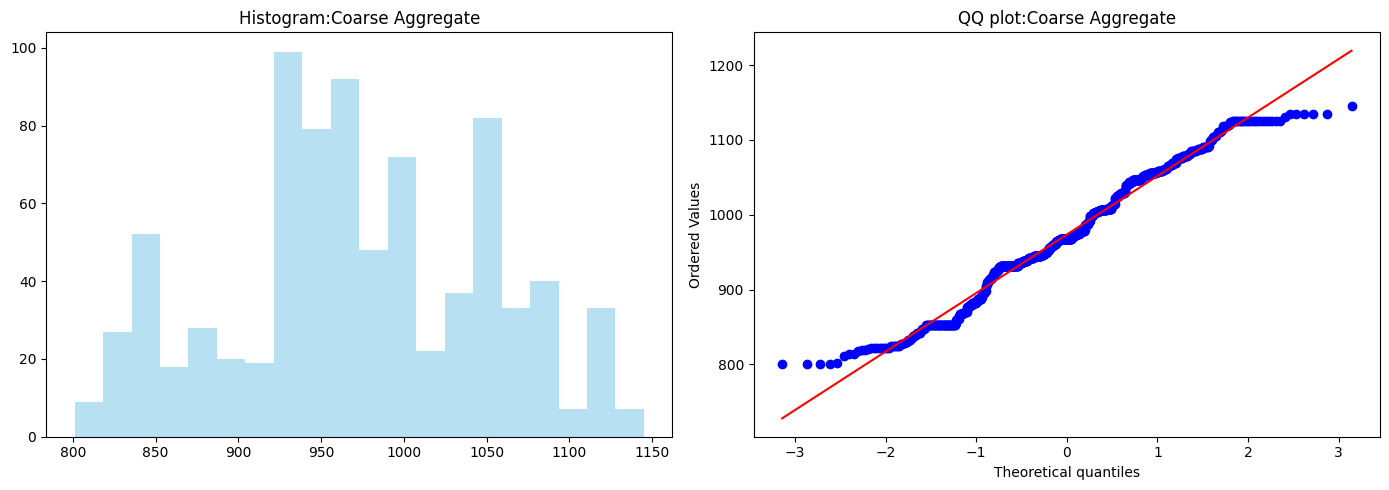

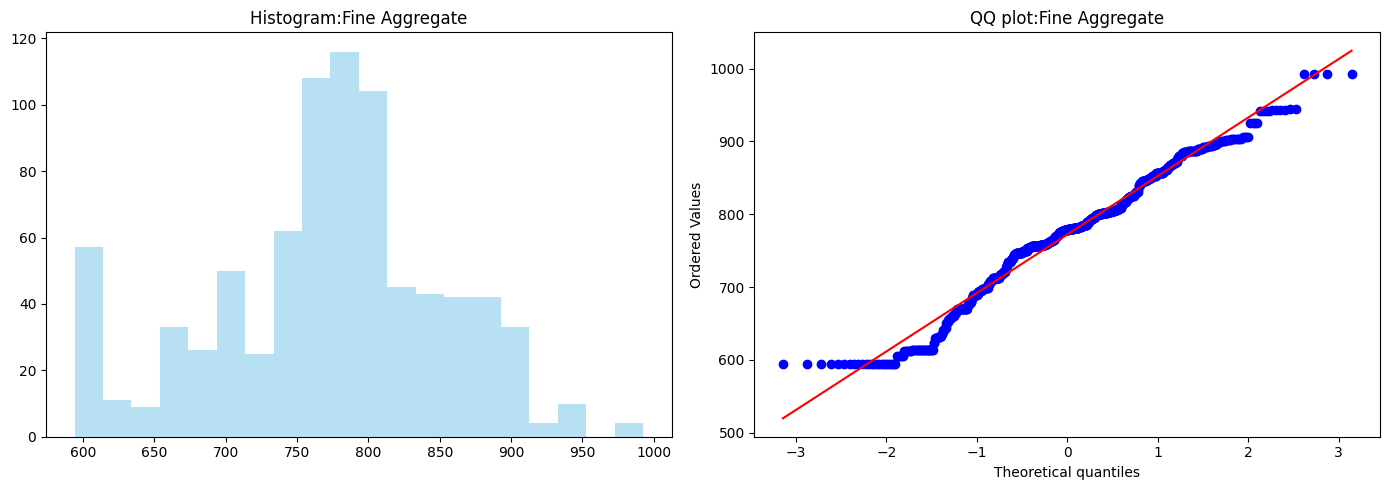

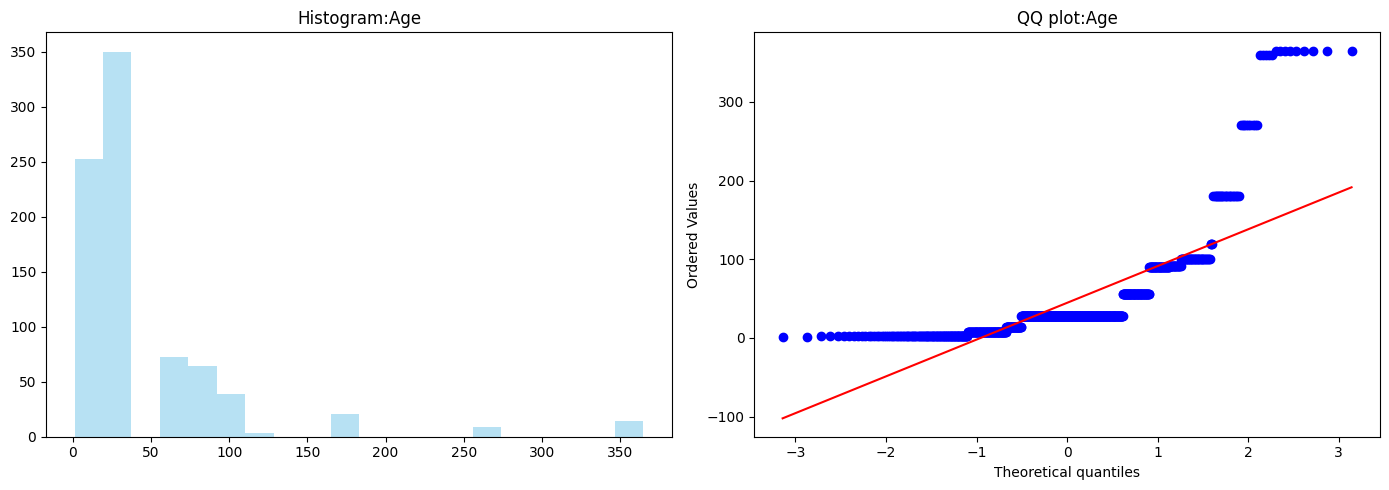

In [61]:
for cols in X_train.columns:
    fig, axs= plt.subplots(1,2,figsize=(14,5))

    ## Histogram
    axs[0].hist(X_train[cols],bins=20,color='skyblue',alpha=0.6)
    axs[0].set_title(f'Histogram:{cols}')

    ## QQ plot
    stats.probplot(X_train[cols],dist='norm',plot=axs[1])
    axs[1].set_title(f'QQ plot:{cols}')

    plt.tight_layout()
    plt.show()

## Without power transformer

In [62]:
## applying linear regression

lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
r2_score(y_test,y_pred)

0.6275531792314848

## Applying Box-Cox Transform


In [64]:
pt=PowerTransformer(method='box-cox') ## default:yeo-johnson
X_train_transformed=pt.fit_transform(X_train+0.000001) ## to avoid error
X_test_transformed=pt.transform(X_test+0.000001)

## applying linear regression 

lr1=LinearRegression()
lr1.fit(X_train_transformed,y_train)
y_pred=lr1.predict(X_test_transformed)
r2_score(y_test,y_pred)

0.8047825001905891

## Applying yeo-johnson transform 

In [68]:
pt2=PowerTransformer(method='yeo-johnson')
X_train_transformed=pt2.fit_transform(X_train+0.000001) ## to avoid error
X_test_transformed=pt2.transform(X_test+0.000001)

## applying linear regression 

lr1=LinearRegression()
lr1.fit(X_train_transformed,y_train)
y_pred=lr1.predict(X_test_transformed)
r2_score(y_test,y_pred)

## use most of the times yeo-johnson

0.8161906532945338

## Quantile Transformer

QuantileTransformer is a preprocessing technique in sklearn.preprocessing that transforms the distribution of a feature to follow a specified target distribution.

The two supported target distributions are:

1. Uniform Distribution (output_distribution='uniform') → values become distributed between 0 and 1.

2. Normal Distribution (output_distribution='normal') → values become approximately Gaussian (mean ≈ 0, std ≈ 1).

Unlike StandardScaler or MinMaxScaler, QuantileTransformer is rank-based, meaning it uses the ordering of values rather than their actual magnitudes.

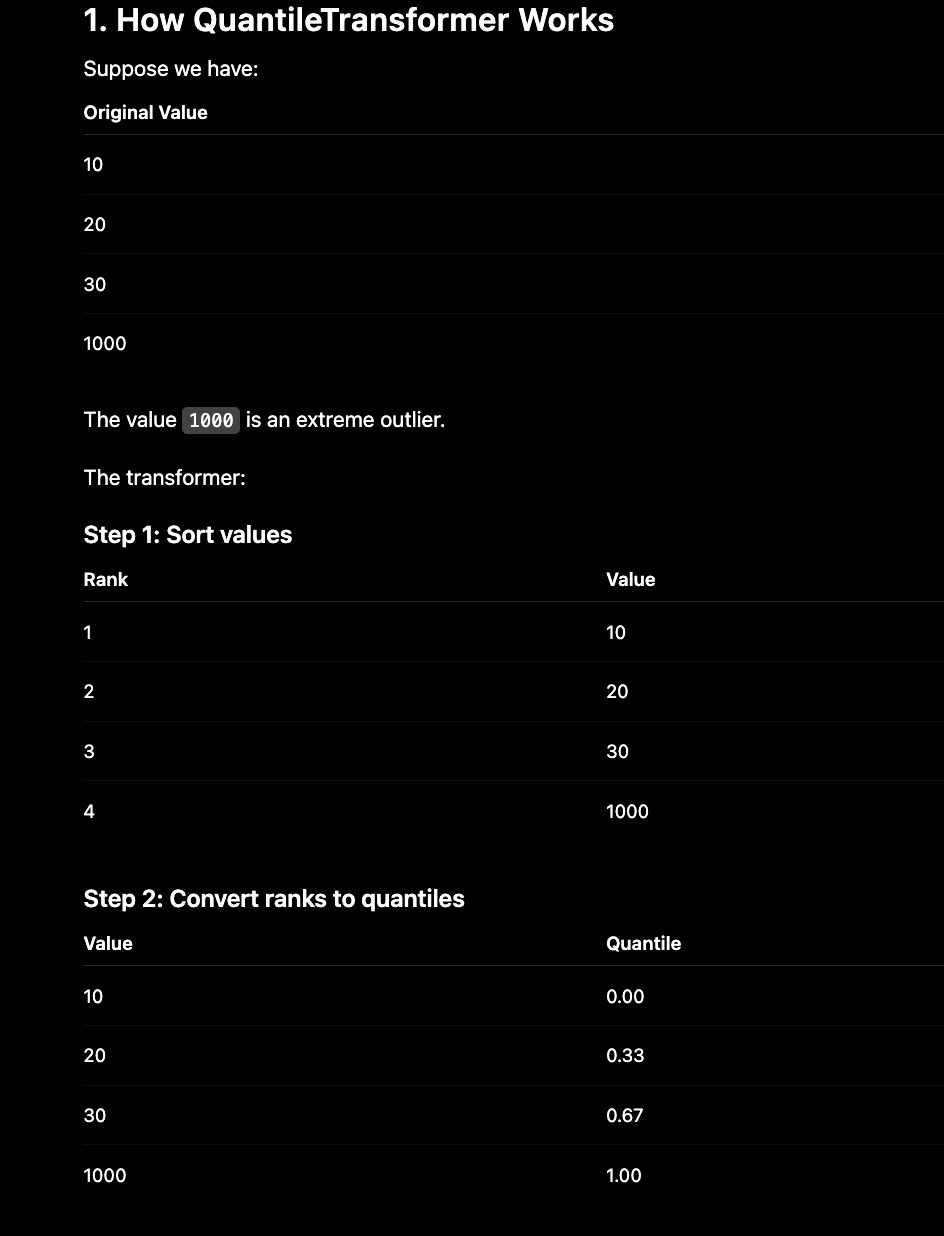

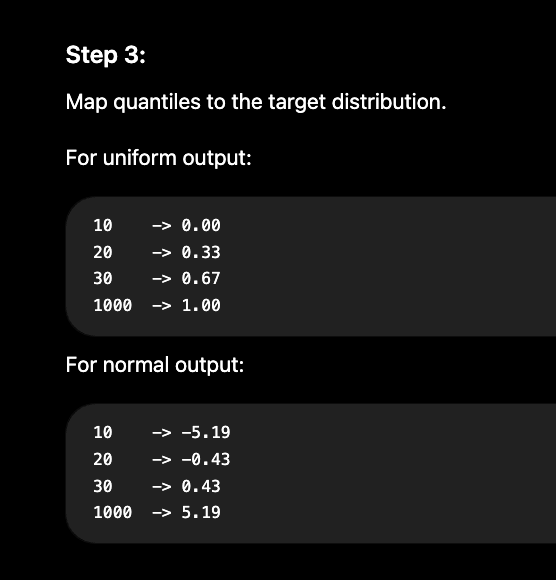

In [1]:
from sklearn.preprocessing import QuantileTransformer
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "income": [20, 22, 24, 26, 28, 30, 35, 40, 45, 1000]
})
df

,income
0,20
1,22
2,24
3,26
4,28
5,30
6,35
7,40
8,45
9,1000


In [3]:
qt_uniform=QuantileTransformer(
    output_distribution='uniform',
    random_state=42
)
df["income_uniform"] = qt_uniform.fit_transform(df[["income"]])
df
## Values are now evenly spread between 0 and 1.


/Users/priyanshugupta/Desktop/scikit learn/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (10). n_quantiles is set to n_samples.
  warnings.warn(


,income,income_uniform
0,20,0.000000
1,22,0.111111
2,24,0.222222
3,26,0.333333
4,28,0.444444
5,30,0.555556
6,35,0.666667
7,40,0.777778
8,45,0.888889
9,1000,1.000000


In [4]:
qt_uniform=QuantileTransformer(
    output_distribution='normal',
    random_state=42
)
df["income_normal"] = qt_uniform.fit_transform(df[["income"]])
df
## Values are now evenly spread between 0 and 1.


/Users/priyanshugupta/Desktop/scikit learn/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (10). n_quantiles is set to n_samples.
  warnings.warn(


,income,income_uniform,income_normal
0,20,0.000000,-5.199338
1,22,0.111111,-1.220640
2,24,0.222222,-0.764710
3,26,0.333333,-0.430727
4,28,0.444444,-0.139710
5,30,0.555556,0.139710
6,35,0.666667,0.430727
7,40,0.777778,0.764710
8,45,0.888889,1.220640
9,1000,1.000000,5.199338


In [5]:
# n_quantiles

# Default:

# n_quantiles=1000

# Number of quantiles used to estimate the cumulative distribution function.

In [6]:
# Why Use QuantileTransformer?
# Handles Outliers Extremely Well
# Makes Data more Guassian